In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from pandas.plotting import table
from PIL import Image

from xbbg import blp
from datetime import datetime, timedelta

from scipy.stats import percentileofscore

In [ ]:
def BaseVolAdjRRDataDaily(ccy, tenor, timeHist):
    day = timeHist
    start_date = (datetime.today() - timedelta(days=(day * 2))).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')
    ticker_IV = f"{ccy}V{tenor} BGN Curncy"
    field = "PX_LAST"
    data_IV = blp.bdh(
        tickers=ticker_IV,
        flds=field,
        start_date=start_date,
        end_date=end_date)
    data_IV = data_IV.tail(day)
    ticker_RR = f"{ccy}25R{tenor} BGN Curncy" h
    field = "PX_LAST"
    data_RR = blp.bdh(
        tickers=ticker_RR,
        flds=field,
        start_date=start_date,
        end_date=end_date)
    data_RR = data_RR.tail(day)
    combined_data = pd.concat([data_IV, data_RR], axis=1)
    combined_data.columns = [f'V{tenor}', f'25r{tenor}']
    combined_data[f'{tenor}_VolAdjRR'] = combined_data[f'25r{tenor}'] / combined_data[f'V{tenor}']
    return combined_data


# Calulating the 3M and 1Y Percentiles of VolAdjRRs -- (If want to Plot, plot=True) -- Outputs: df with percentils of VolAdjustedRRs
def BaseVolAdjRREval(ccy, tenors, timeHist, plot): 
    df_allVolAdjRRs = pd.DataFrame()
    for tenor in tenors:
        df_tenor = BaseVolAdjRRDataDaily(ccy, tenor, timeHist)
        if df_allVolAdjRRs.empty:
            df_allVolAdjRRs = df_tenor
        else:
            df_allVolAdjRRs = df_allVolAdjRRs.join(df_tenor, how='outer')
    tenor_data = []
    tenors = ['1W', '1M', '3M', '6M', '1Y']
    for tenor in tenors:
        tenor_row = {
            'Tenor': tenor,
            '25D RR': df_allVolAdjRRs[f'25r{tenor}'].iloc[-1],  
            'ATM Vol': df_allVolAdjRRs[f'V{tenor}'].iloc[-1],  
            'VolAdjRR': df_allVolAdjRRs[f'{tenor}_VolAdjRR'].iloc[-1]}
        tenor_data.append(tenor_row)
    df_reshaped = pd.DataFrame(tenor_data)
    df_allVolAdjRRs.index = pd.to_datetime(df_allVolAdjRRs.index)
    three_months_ago = pd.Timestamp(df_allVolAdjRRs.index[-1]) - pd.DateOffset(months=3)
    one_year_ago = pd.Timestamp(df_allVolAdjRRs.index[-1]) - pd.DateOffset(years=1)
    percentile_data = []
    for tenor in df_reshaped['Tenor']:
        vol_adj_rr_col = f'{tenor}_VolAdjRR'
        past_3m_data = df_allVolAdjRRs.loc[df_allVolAdjRRs.index >= three_months_ago, vol_adj_rr_col]
        past_1y_data = df_allVolAdjRRs.loc[df_allVolAdjRRs.index >= one_year_ago, vol_adj_rr_col]
        current_value = df_reshaped.loc[df_reshaped['Tenor'] == tenor, 'VolAdjRR'].values[0]
        three_months_percentile = percentileofscore(past_3m_data, current_value, kind='rank')
        one_year_percentile = percentileofscore(past_1y_data, current_value, kind='rank')
        percentile_data.append({
            'Tenor': tenor,
            '3M Percentile': three_months_percentile,
            '1Y Percentile': one_year_percentile})
    df_percentiles = pd.DataFrame(percentile_data)
    df_reshaped = pd.merge(df_reshaped, df_percentiles, on='Tenor')
    df_reshaped['3M Percentile'] = df_reshaped['3M Percentile'].round(0).astype(str) + '%'
    df_reshaped['1Y Percentile'] = df_reshaped['1Y Percentile'].round(0).astype(str) + '%'
    df_reshaped.rename(columns={
        '25D RR': '25D Risk Reversal',
        'ATM Vol': 'At-The-Money Volatility',
        'VolAdjRR': 'Volatility Adjusted RR',
        '3M Percentile': '3-Month Percentile',
        '1Y Percentile': '1-Year Percentile'}, inplace=True)
    df_reshaped.set_index('Tenor', inplace=True)
    if plot == True:
        columns_to_plot = ['1W_VolAdjRR', '1M_VolAdjRR', '3M_VolAdjRR', '6M_VolAdjRR', '1Y_VolAdjRR']
        titles = ['1W VolAdjRR', '1M VolAdjRR', '3M VolAdjRR', '6M VolAdjRR', '1Y VolAdjRR']
        fig, axes = plt.subplots(3, 2, figsize=(15, 10))
        axes = axes.flatten()
        for i, col in enumerate(columns_to_plot):
            ax = axes[i]
            ax.plot(df_allVolAdjRRs.index, df_allVolAdjRRs[col], label=col, color=f'C{i}')
            ax.set_title(titles[i])
            ax.set_xlabel('Date')
            ax.set_ylabel('VolAdjRR')
            ax.legend()
            ax.grid(True)
        axes[-1].axis('off')
        plt.tight_layout()
        plt.suptitle("EURUSD Vol Adjusted Risk Reversal  by Tenor", fontsize=16, fontweight='bold', y=1.02)
        plt.show()
    return df_reshaped

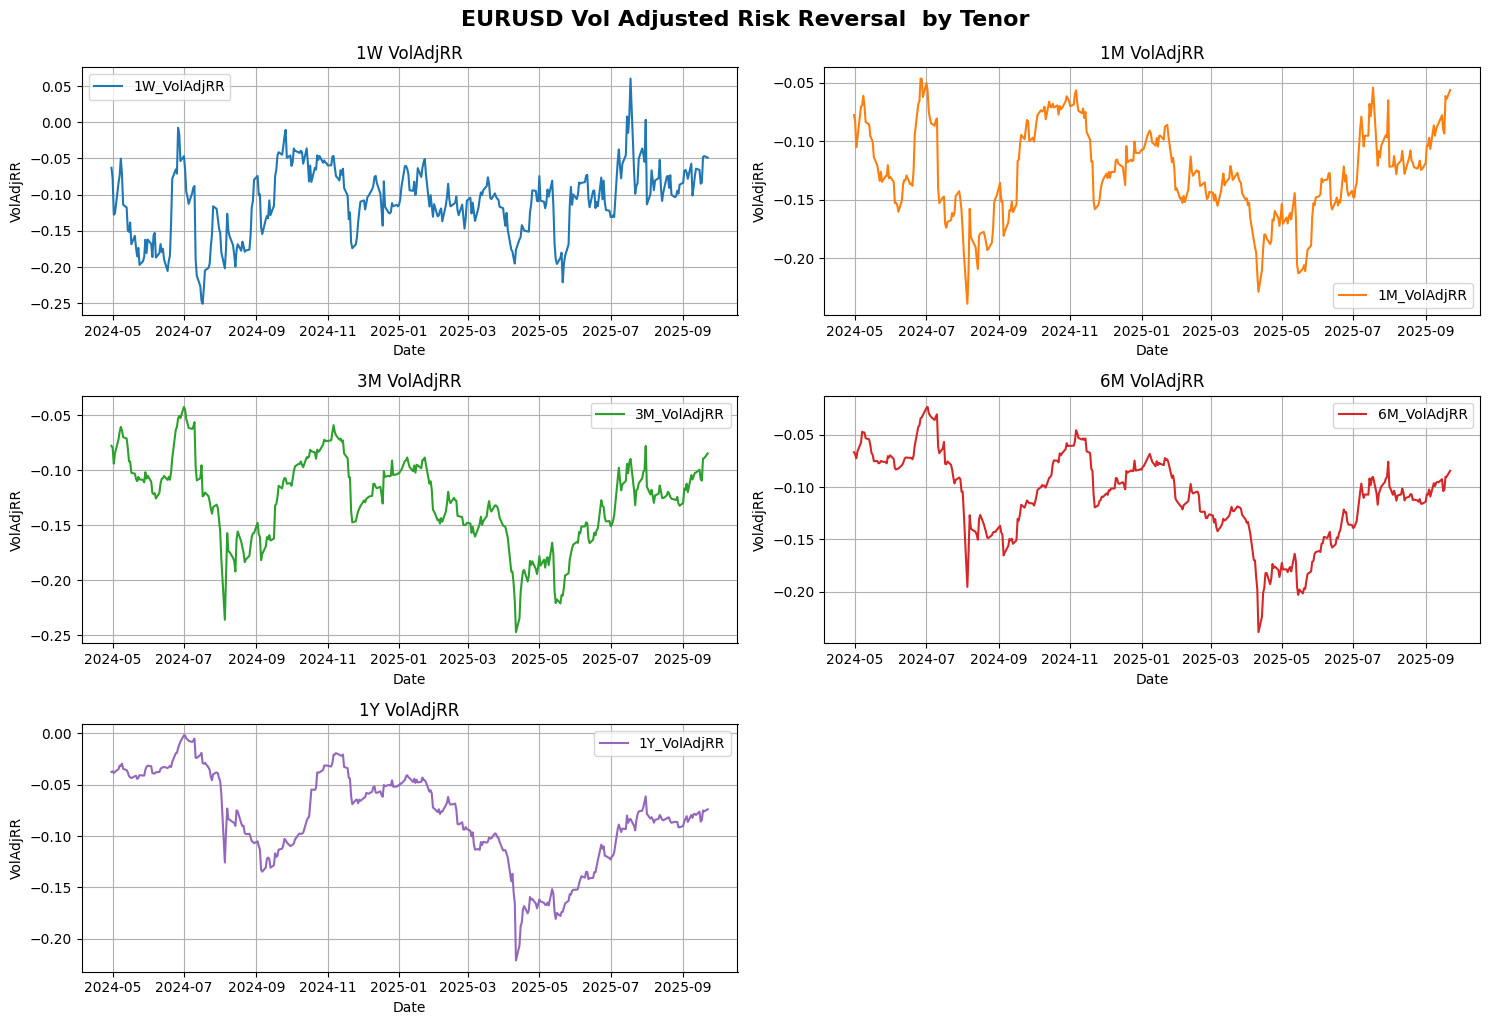

In [3]:
eurusd = 'EURUSD'
usdjpy = 'USDJPY'
usdchf = 'USDCHF'

tenors = ['1W', '1M', '3M', '6M', '1Y']
timeHist = 365




df_eurusdADJRRPercentiles  = BaseVolAdjRREval(usdjpy, tenors, timeHist, True )


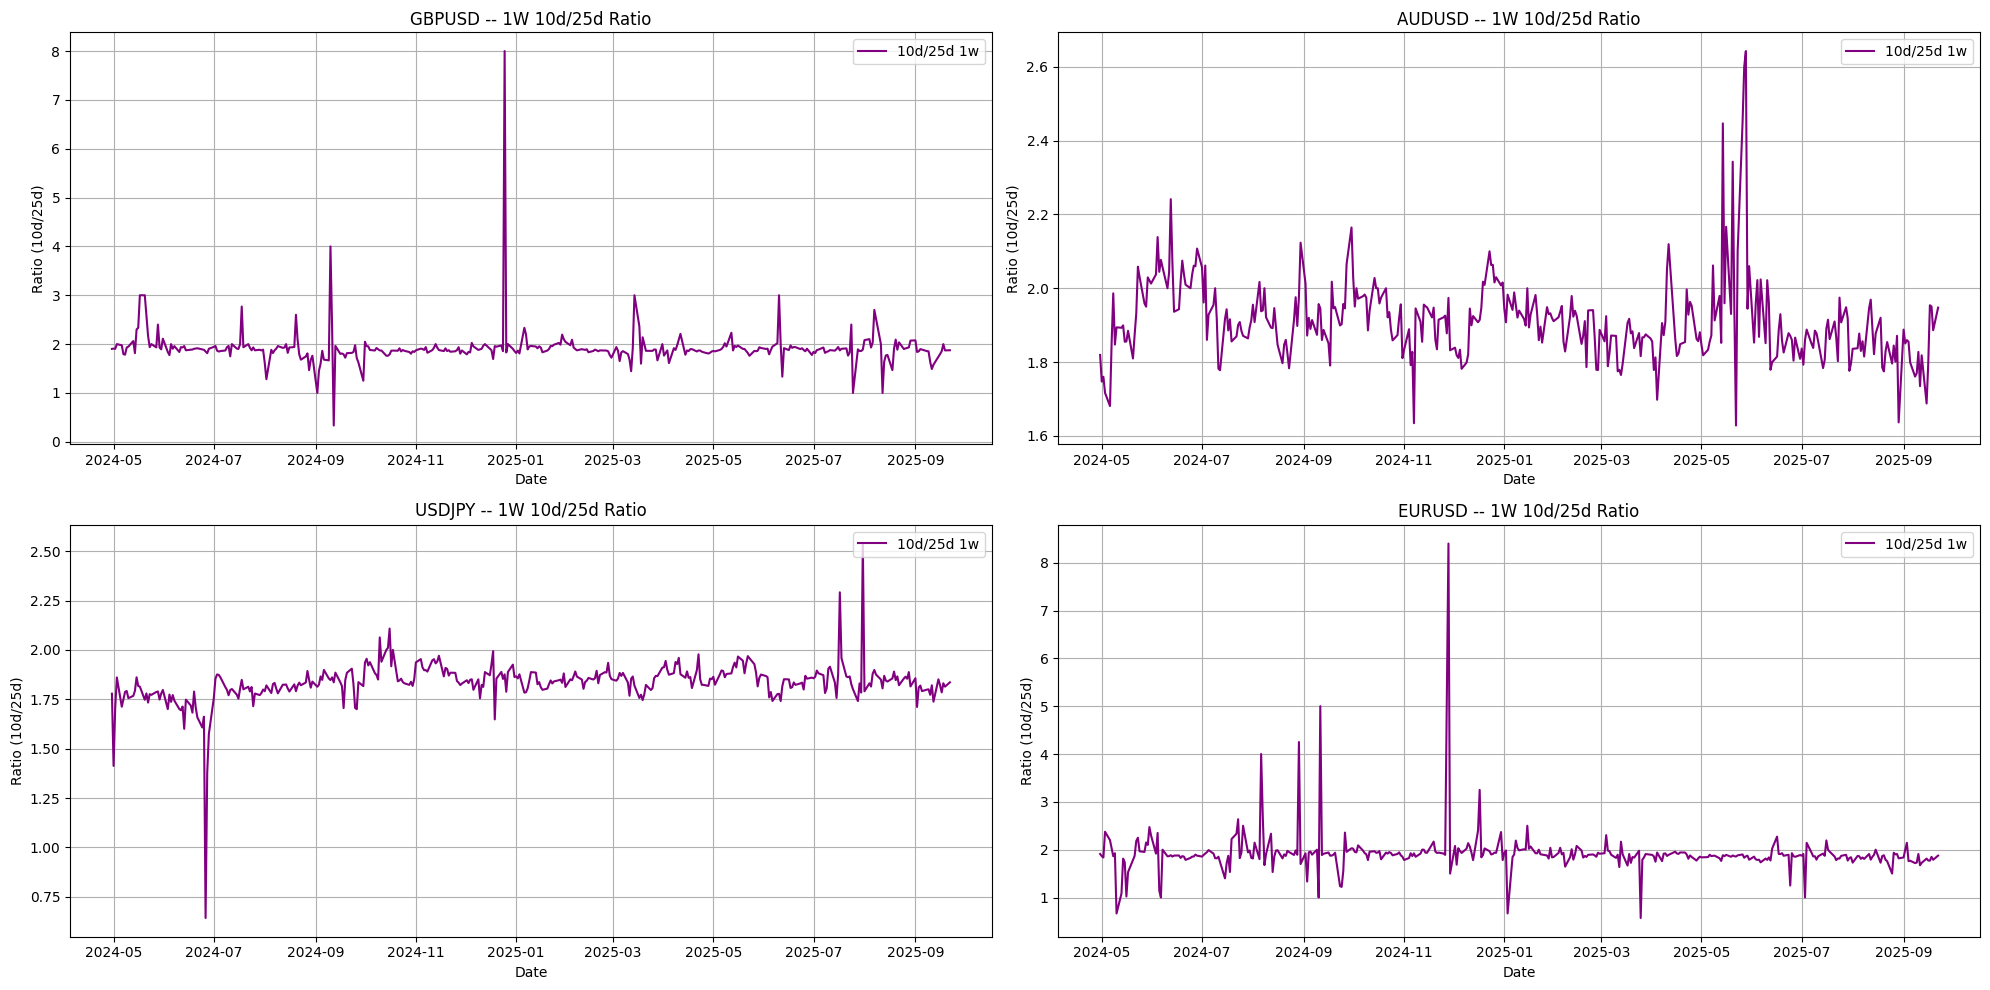

In [ ]:
ccy_pairs = ['GBPUSD', 'AUDUSD', 'USDJPY', 'EURUSD']


timeHist = 365
day = timeHist
start_date = (datetime.today() - timedelta(days=(day * 2))).strftime('%Y-%m-%d')
end_date = datetime.today().strftime('%Y-%m-%d')


fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten() 

for i, ccy in enumerate(ccy_pairs):    
    ticker_IV = f"{ccy}10R1W BGN Curncy"
    ticker_IV2 = f"{ccy}25R1W BGN Curncy"
    data_IV = blp.bdh(tickers=ticker_IV, flds="PX_LAST", start_date=start_date, end_date=end_date).tail(day)
    data_IV2 = blp.bdh(tickers=ticker_IV2, flds="PX_LAST", start_date=start_date, end_date=end_date).tail(day)
    
    
    combined_data = pd.concat([data_IV, data_IV2], axis=1)
    combined_data.columns = [f'{ccy}10R1W', f'{ccy}25R1W']
    combined_data['Ratio'] = combined_data[f'{ccy}10R1W'] / combined_data[f'{ccy}25R1W']
    
    
    combined_data = combined_data[(combined_data['Ratio'] >= 0) & (combined_data['Ratio'] <= 10)]
    
    
    ax = axes[i]
    ax.plot(combined_data.index, combined_data['Ratio'], color='purple', label='10d/25d 1w')
    ax.set_title(f'{ccy} -- 1W 10d/25d Ratio')
    ax.set_xlabel('Date')
    ax.set_ylabel('Ratio (10d/25d)')
    ax.legend(loc='upper right')
    ax.grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import table
from PIL import Image
from xbbg import blp
from datetime import datetime, timedelta

from scipy.stats import percentileofscore
import math


In [60]:
def CompareVolMetricsToHistory(ccys, tenors, days_back):
    current_date = datetime.today().strftime('%Y-%m-%d')
    hist_date = (datetime.today() - timedelta(days=days_back)).date()
    start_date = (datetime.today() - timedelta(days=(days_back + 10))).strftime('%Y-%m-%d')
    results = []
    for ccy in ccys:
        for tenor in tenors:
            ticker_IV = f"{ccy}V{tenor} BGN Curncy"
            data_IV = blp.bdh(tickers=ticker_IV, flds="PX_LAST", 
                              start_date=start_date, end_date=current_date)
            ticker_RR = f"{ccy}25R{tenor} BGN Curncy"
            data_RR = blp.bdh(tickers=ticker_RR, flds="PX_LAST",
                              start_date=start_date, end_date=current_date)
            ticker_BF = f"{ccy}10B{tenor} BGN Curncy"
            data_BF = blp.bdh(tickers=ticker_BF, flds="PX_LAST",
                              start_date=start_date, end_date=current_date)
            iv_current = data_IV.iloc[-1].values[0]
            rr_current = data_RR.iloc[-1].values[0]
            bf_current = data_BF.iloc[-1].values[0]
            iv_hist = data_IV.loc[:hist_date].iloc[-1].values[0]
            rr_hist = data_RR.loc[:hist_date].iloc[-1].values[0]
            bf_hist = data_BF.loc[:hist_date].iloc[-1].values[0]
            vol_adj_rr_current = rr_current / iv_current
            vol_adj_rr_hist = rr_hist / iv_hist
            vol_adj_bf_current = bf_current / iv_current
            vol_adj_bf_hist = bf_hist / iv_hist
            results.append({
                'CCY': ccy,
                'Tenor': tenor,
                'ATM_Current': iv_current,
                'ATM_Hist': iv_hist,
                'ATM_Chg': iv_current - iv_hist,
                'ATM_Chg_Pct': ((iv_current / iv_hist) - 1) * 100,
                'RR_Current': rr_current,
                'RR_Hist': rr_hist,
                'RR_Chg': rr_current - rr_hist,
                'VolAdjRR_Current': vol_adj_rr_current,
                'VolAdjRR_Hist': vol_adj_rr_hist,
                'VolAdjRR_Chg': vol_adj_rr_current - vol_adj_rr_hist,
                'BF_Current': bf_current,
                'BF_Hist': bf_hist,
                'BF_Chg': bf_current - bf_hist,
                'VolAdjBF_Current': vol_adj_bf_current,
                'VolAdjBF_Hist': vol_adj_bf_hist,
                'VolAdjBF_Chg': vol_adj_bf_current - vol_adj_bf_hist})
    return pd.DataFrame(results)

In [61]:
def plot_vol_changes_heatmap_multi_ccy_flexible(comparison_df, n_cols=2):

    ccys = comparison_df['CCY'].unique()
    n_ccys = len(ccys)
    
    # Calculate rows needed
    n_rows = math.ceil(n_ccys / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 4*n_rows))
    
    # Flatten axes array for easy iteration
    if n_ccys == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    
    for i, ccy in enumerate(ccys):
        ccy_data = comparison_df[comparison_df['CCY'] == ccy]
        heatmap_data = ccy_data[['Tenor', 'ATM_Chg', 'RR_Chg', 'BF_Chg']].set_index('Tenor').T
        heatmap_normalized = heatmap_data.apply(lambda row: (row - row.mean()) / row.std(), axis=1)
        annot_data = heatmap_data.copy()
        
        sns.heatmap(heatmap_normalized, annot=annot_data, fmt='.4f', cmap='RdYlGn', center=0,
                    linewidths=1, linecolor='white', 
                    cbar_kws={'label': 'Normalized Color Scale Change'},
                    ax=axes[i], vmin=-2, vmax=2)
        
        axes[i].set_ylabel('Metric', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Tenor', fontsize=11, fontweight='bold')
        axes[i].set_title(f'{ccy}', fontsize=12, fontweight='bold')
        axes[i].set_yticklabels(['ATM', '25D RR', '10D BF'], rotation=0)
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle('Vol Changes - Friday Close to Now', 
                 fontsize=14, fontweight='bold', y=0.998)
    plt.tight_layout()
    plt.show()


Comparing to: 2025-10-17


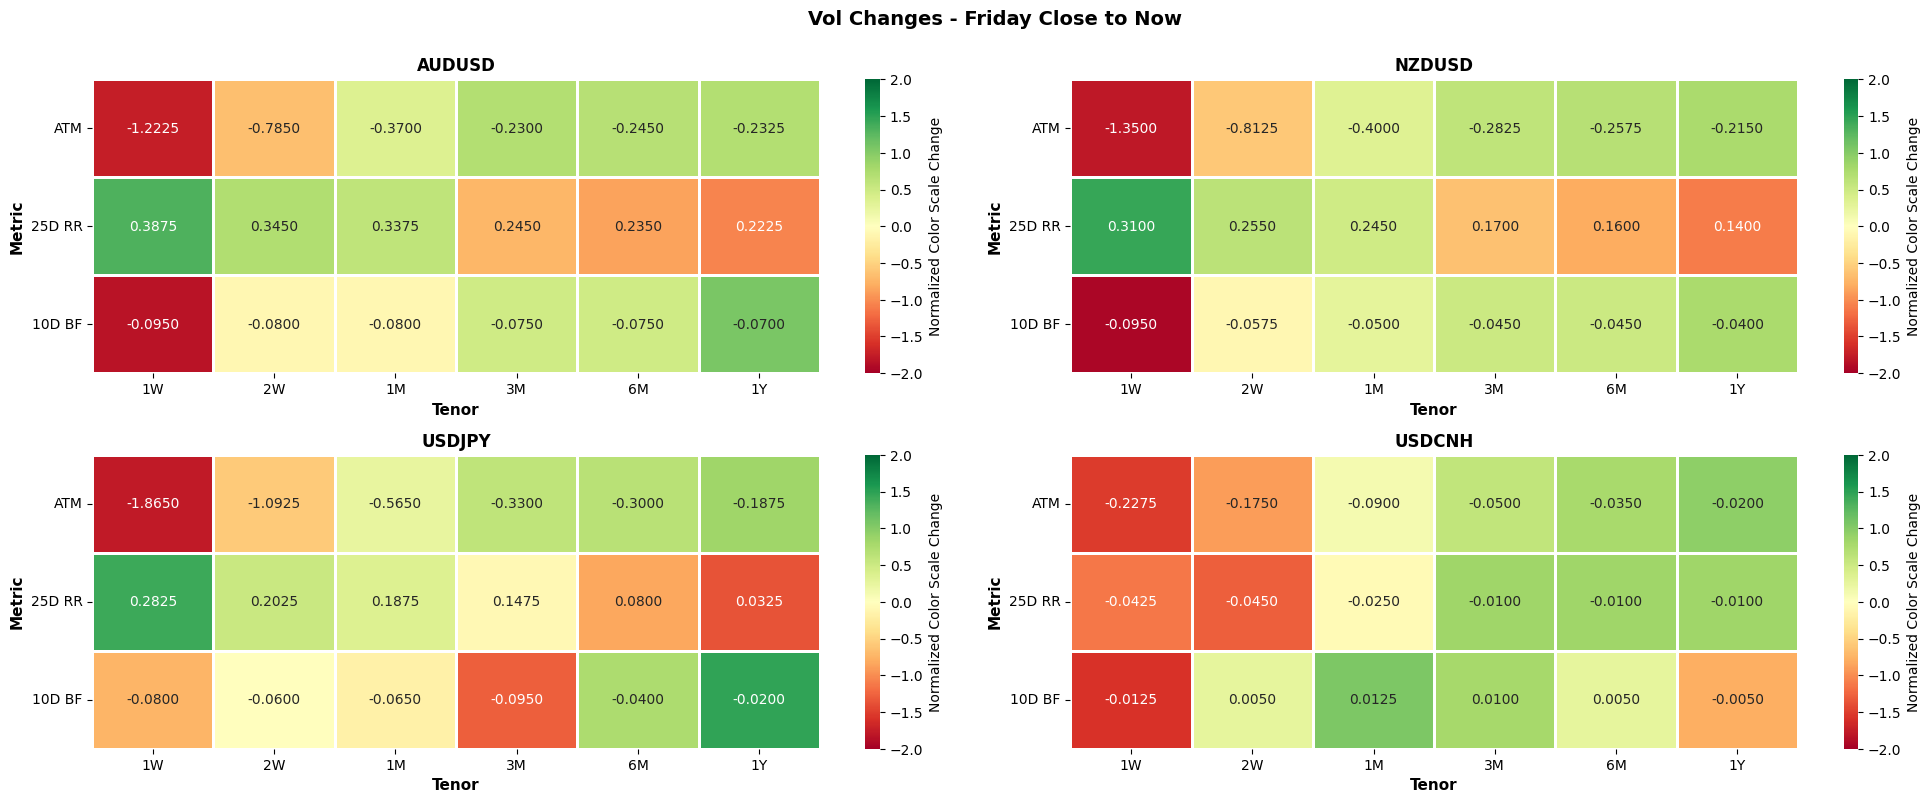

In [58]:
ccy = ['AUDUSD', 'NZDUSD', 'USDJPY', 'USDCNH']
tenors = ['1W', '2W', '1M', '3M', '6M', '1Y']
comparison = CompareVolMetricsToHistory(ccy, tenors, days_back=3)
plot_vol_changes_heatmap_multi_ccy_flexible(comparison)